In [1]:
#Importing Libraries that are required for data analysis, visualization, and preprocessing.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style = 'whitegrid')

In [3]:
df = pd.read_csv('fraud.csv')

In [4]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info() #Getting information about the Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df['isFraud'].value_counts() #To count the actual fraud

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
df['isFlaggedFraud'].value_counts() #Counting the potential fraud

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [11]:
df.isnull().sum().sum() 

np.int64(0)

In [12]:
df.shape

(6362620, 11)

In [13]:
round((df['isFraud'].value_counts()[1] / df.shape[0]) * 100, 2) #Fraud Percentage

np.float64(0.13)

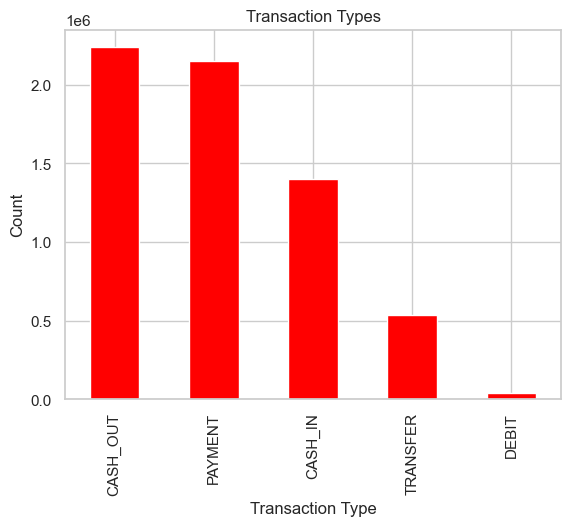

In [14]:
df['type'].value_counts().plot(kind = 'bar', title = 'Transaction Types', color = 'Red')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

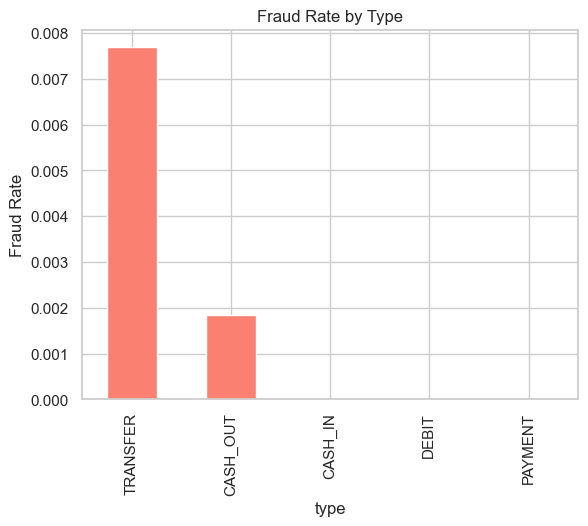

In [15]:
#Fraud by different types of payment.
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending = False)
fraud_by_type.plot(kind = 'bar', title = 'Fraud Rate by Type', color = 'Salmon')
plt.ylabel('Fraud Rate')
plt.show()

In [16]:
df['amount'].describe().astype(int) #Summary statistics of transaction amount for understanding distribution

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

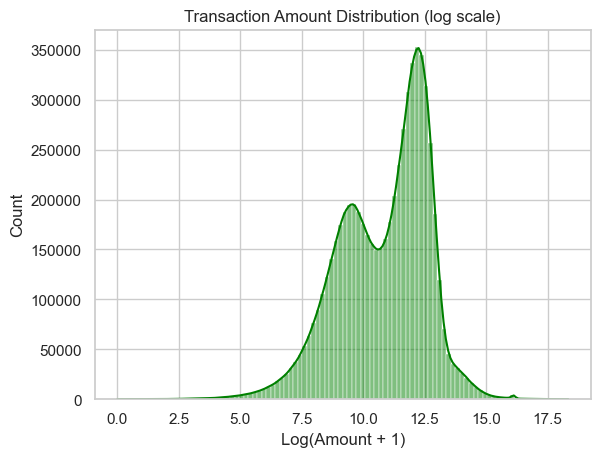

In [17]:
sns.histplot(np.log1p(df['amount']), bins = 100, kde = True, color = 'Green')
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('Log(Amount + 1)')
plt.show()

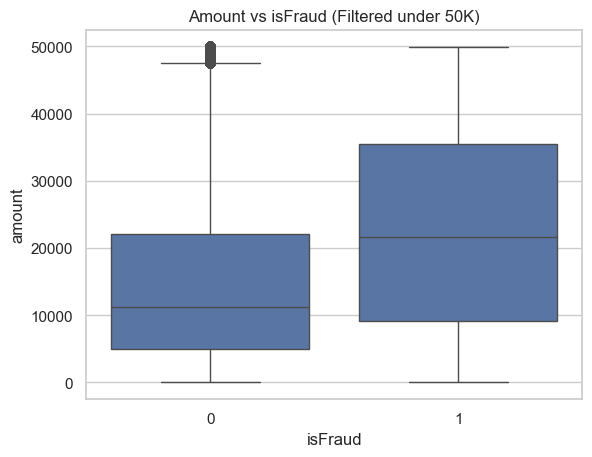

In [19]:
sns.boxplot(data = df[df['amount'] < 50000], x = 'isFraud', y = 'amount')
plt.title('Amount vs isFraud (Filtered under 50K)')
plt.show()

In [20]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']


In [21]:
(df['balanceDiffOrig']<0).sum()

np.int64(1399253)

In [22]:
(df['balanceDiffDest'] < 0).sum()

np.int64(1238864)

In [23]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


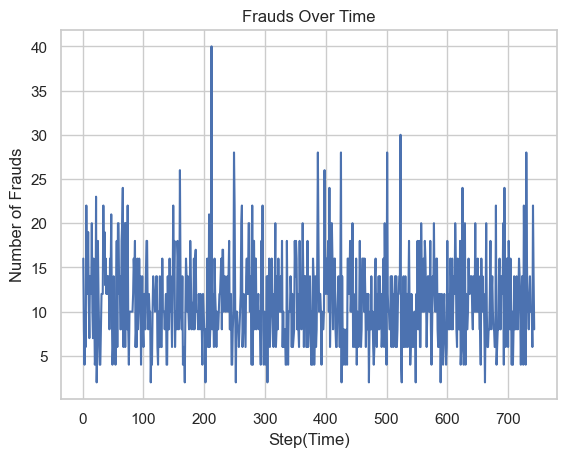

In [24]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index,frauds_per_step.values,label='Frauds per Step')
plt.xlabel('Step(Time)')
plt.ylabel('Number of Frauds')
plt.title('Frauds Over Time')
plt.grid(True)
plt.show()

In [25]:
df.drop(columns = 'step', inplace = True)

In [26]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [27]:
top_senders = df['nameOrig'].value_counts().head(10)

In [28]:
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [29]:
top_receivers = df['nameDest'].value_counts().head(10)

In [30]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [31]:
fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)

In [32]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [33]:
fraud_types = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [34]:
fraud_types['type'].value_counts() #Fraud by transaction type.

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

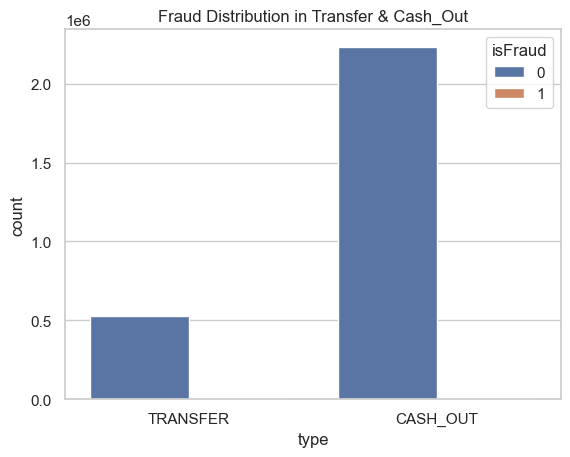

In [35]:
sns.countplot(data=fraud_types, x = 'type', hue = 'isFraud')
plt.title('Fraud Distribution in Transfer & Cash_Out')
plt.show()

In [36]:
#Computing correlation matrix to analyze relationships between transaction features and fraud.
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

In [37]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


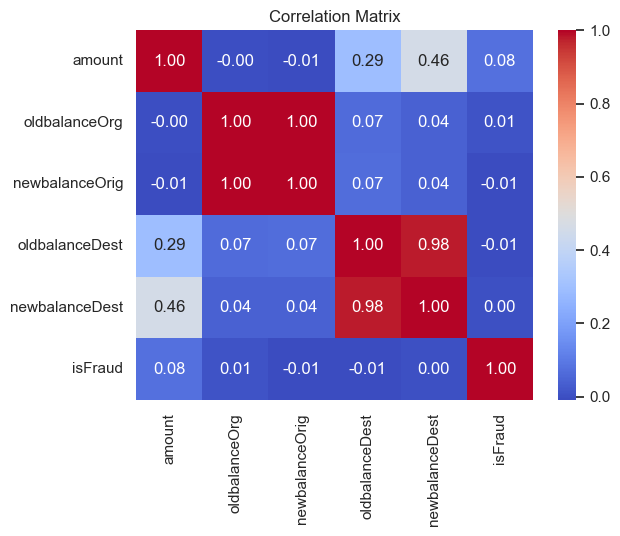

In [38]:
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix')
plt.show()

In [39]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
    ]

In [40]:
len(zero_after_transfer)

1188074

In [41]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [42]:
#Importing libraries for data preprocessing, model building, and evaluation.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [43]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [44]:
df_model = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1)

In [45]:
#Separating categorical and numerical features for preprocessing (encoding and scaling)
categorical = ['type']
numeric = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

In [46]:
#Splitting dataset into features (X) and target variable (y) for model training. 
y = df_model['isFraud']
X = df_model.drop('isFraud', axis = 1)

In [47]:
#Splitting dataset into training and testing sets while maintaining class distribution using stratification.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)

In [48]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop = 'first'), categorical)
    ],
    remainder = 'drop'
)

In [49]:
#Creating a pipeline to combine preprocessing and model training steps.
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight = 'balanced', max_iter = 1000))
])

In [50]:
#Training the pipeline on training data.
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
y_pred = pipeline.predict(X_test)

In [52]:
#Evaluating model performance using classification metrics.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [53]:
#Generating confusion matrix to evaluate model predictions against actual values.
confusion_matrix(y_test, y_pred)

array([[1804066,  102256],
       [    123,    2341]])

In [54]:
#Calculating model accuracy on test data.
pipeline.score(X_test, y_test) * 100

94.63643383805204

In [88]:
#The model got 94% accuracy.

In [55]:
#Saving the trained pipeline model to a file for future use.
import joblib
joblib.dump(pipeline,'fraud_detection_pipeline2026.pkl')

['fraud_detection_pipeline2026.pkl']